      Task 2.1: 8-Class KNN Classification


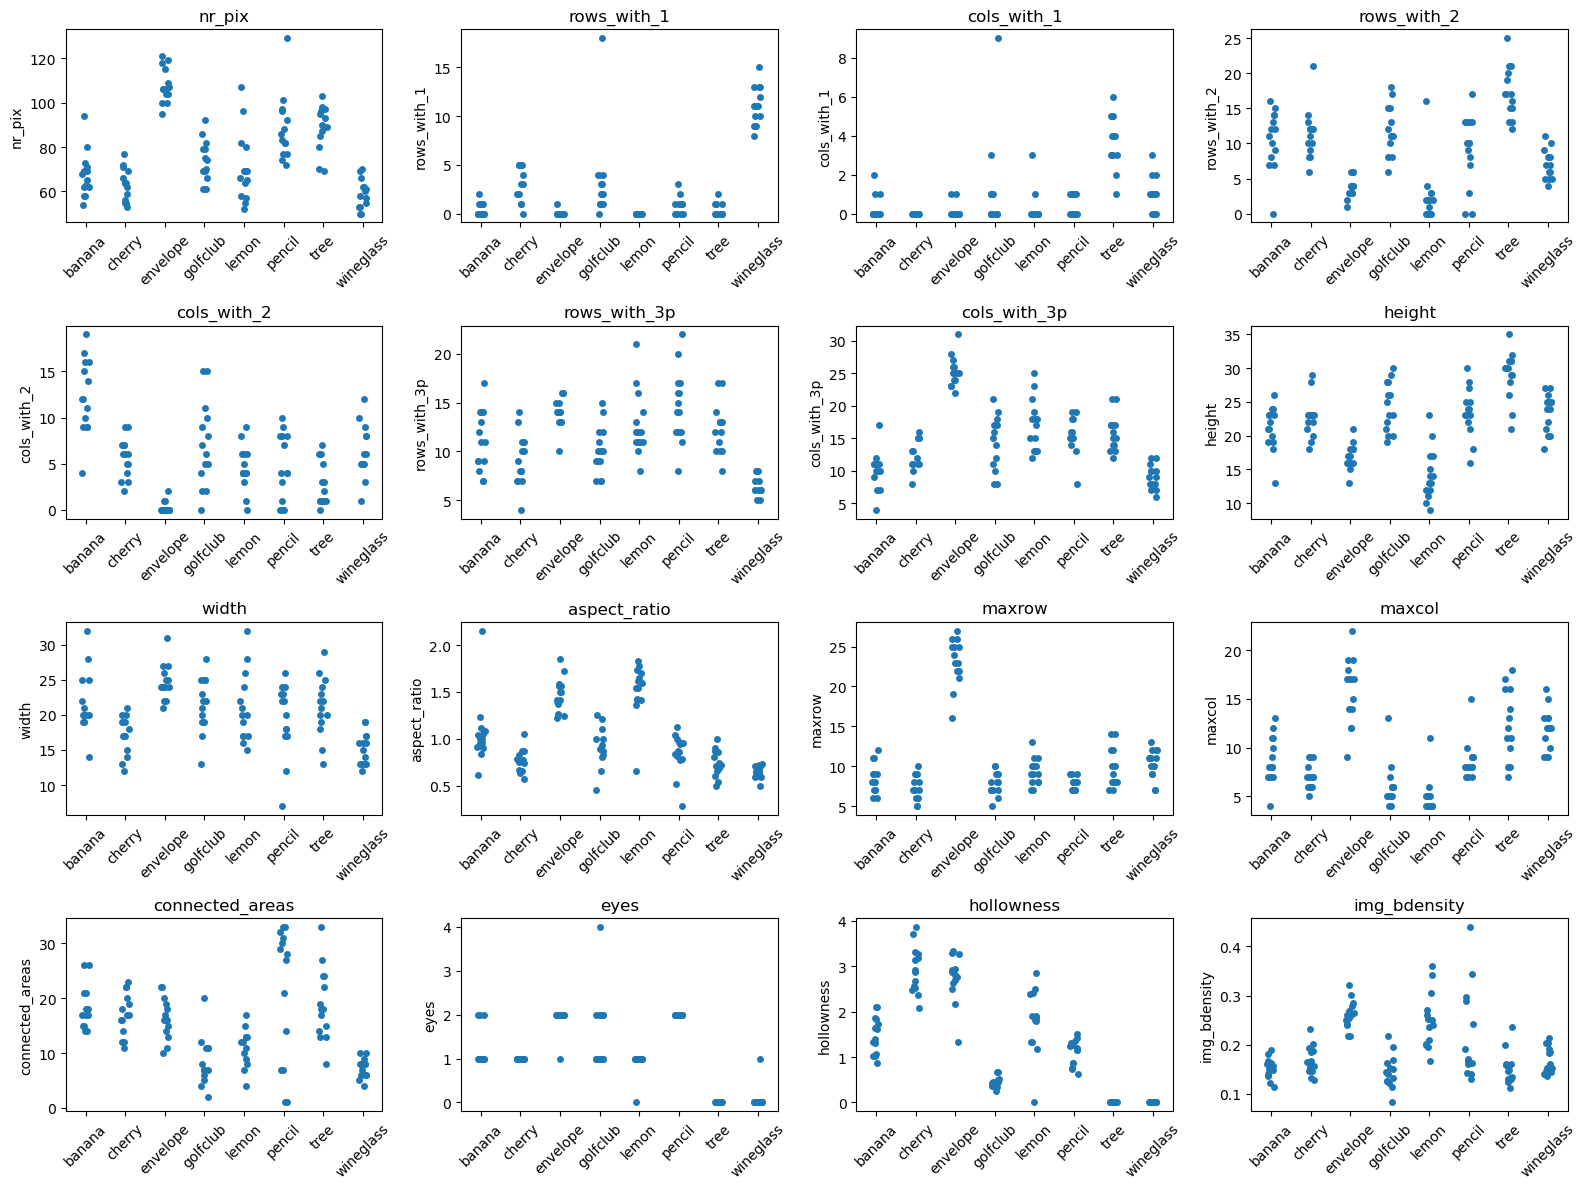

---------------------------------------------
      Task 2.1: KNN model: K value/accuracy
---------------------------------------------
k= 1  Accuracy: 0.9911
k= 3  Accuracy: 0.9375
k= 5  Accuracy: 0.8929
k= 7  Accuracy: 0.8839
k= 9  Accuracy: 0.8393
k=11  Accuracy: 0.8125
k=13  Accuracy: 0.8125
k=15  Accuracy: 0.8125
      Task 2.2: KNN with 7-Fold CV
k= 1  CV Accuracy: 0.8839
k= 3  CV Accuracy: 0.8482
k= 5  CV Accuracy: 0.8214
k= 7  CV Accuracy: 0.8214
k= 9  CV Accuracy: 0.8125
k=11  CV Accuracy: 0.7946
k=13  CV Accuracy: 0.8036
k=15  CV Accuracy: 0.8036
      Task 2.3: Confusion Matrix for k=3


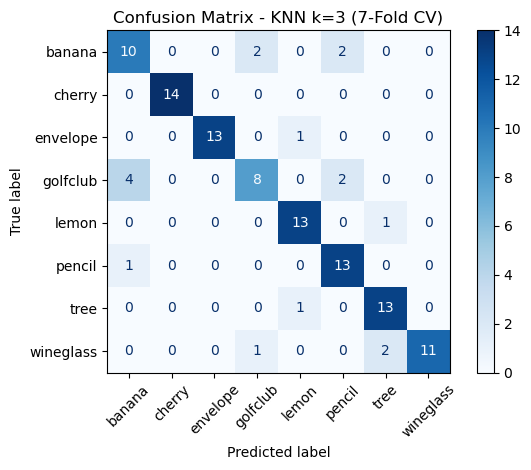

      Task 2.4: Training vs CV Error Rate


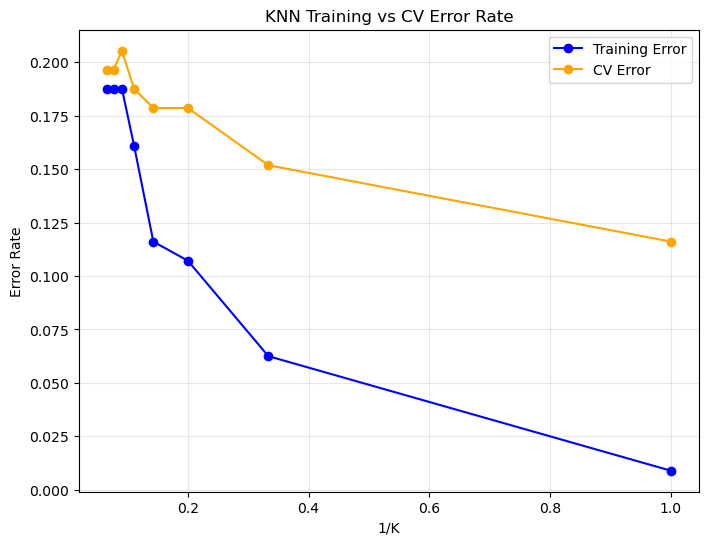

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from sklearn.model_selection import StratifiedKFold


def main():
    
    src = "C:\\Users\\ammar\\Desktop\\A1_Ammar_Jileidan\\features.csv"
    df = pd.read_csv(src)

    #========================================================================================================
    #Task 2.1
    #========================================================================================================

    print("="*45)
    print("      Task 2.1: 8-Class KNN Classification")
    print("="*45)

    # Examine feautres for selection
    all_features = ['nr_pix', 'rows_with_1', 'cols_with_1', 'rows_with_2',
            'cols_with_2', 'rows_with_3p', 'cols_with_3p', 'height',
            'width', 'aspect_ratio', 'maxrow', 'maxcol',
            'connected_areas', 'eyes', 'hollowness', 'img_bdensity']

    fig, axes = plt.subplots(4, 4, figsize=(16, 12))
    axes = axes.flatten()
    
    for i, feature in enumerate(all_features):
        sns.stripplot(data=df, x='label', y=feature, ax=axes[i], jitter=True)
        axes[i].set_title(feature)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    #//////////////////////////////////////////////////////////////////////////////
    # Selected feautres
    features = ['aspect_ratio','eyes', 'hollowness', 'cols_with_2']
    
    # selected feautres and labels extraction 
    X = df[features].values
    y = df['label'].values
    
    # Standardise
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X)

    # K values odd between 1 and 15 inclusive
    k_values = range(1, 16, 2) 
    
    print("-"*45)
    print("      Task 2.1: KNN model: K value/accuracy")
    print("-"*45)
    knn_acc = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_sc, y)
        y_pred = knn.predict(X_sc)
        acc = accuracy_score(y, y_pred)
        knn_acc.append(acc)
        print(f"k={k:2d}  Accuracy: {acc:.4f}")

    #========================================================================================================
    #Task 2.2
    #========================================================================================================



    print("="*45)
    print("      Task 2.2: KNN with 7-Fold CV")
    print("="*45)
    #split data
    skf = StratifiedKFold(n_splits=7, shuffle=True, random_state=42)
    cv_acc = []
    #train and test for each fold and ptint accuracy
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        fold_acc = []
        
        for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
            X_train = X[train_idx]
            X_test  = X[test_idx]
            y_train = y[train_idx]
            y_test  = y[test_idx]
            
            scale = StandardScaler()
            X_train = scale.fit_transform(X_train)
            X_test  = scale.transform(X_test)
            
            knn.fit(X_train, y_train)
            y_pred = knn.predict(X_test)
            fold_acc.append(accuracy_score(y_test, y_pred))
            
        cv_acc.append(np.mean(fold_acc))    
        print(f"k={k:2d}  CV Accuracy: {np.mean(fold_acc):.4f}")

    #========================================================================================================
    #Task 2.3
    #========================================================================================================
    print("="*45)
    print("      Task 2.3: Confusion Matrix for k=3")
    print("="*45)
    
    knn_best = KNeighborsClassifier(n_neighbors=3)
    
    # collect all predictions across folds
    y_true_all = []
    y_pred_all = []
    #train, test and save predictions for evalution
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        X_train_k = X[train_idx]
        X_test_k  = X[test_idx]
        y_train_k = y[train_idx]
        y_test_k  = y[test_idx]
    
        scaler_k    = StandardScaler()
        X_train_k   = scaler_k.fit_transform(X_train_k)
        X_test_k    = scaler_k.transform(X_test_k)
    
        knn_best.fit(X_train_k, y_train_k)
        y_pred_k = knn_best.predict(X_test_k)
    
        y_true_all.extend(y_test_k)
        y_pred_all.extend(y_pred_k)
    
    # Confusion matrix
    classes = sorted(df['label'].unique())
    cm = confusion_matrix(y_true_all, y_pred_all, labels=classes)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix - KNN k=3 (7-Fold CV)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


    print("="*45)
    print("      Task 2.4: Training vs CV Error Rate")
    print("="*45)
    
    k_values = list(range(1, 16, 2))
    inv_k = [1/k for k in k_values]
    
    train_error = [1 - acc for acc in knn_acc]
    cv_error    = [1 - acc for acc in cv_acc]
    
    plt.figure(figsize=(8, 6))
    plt.plot(inv_k, train_error, color='blue', marker='o', label='Training Error')
    plt.plot(inv_k, cv_error,    color='orange', marker='o', label='CV Error')
    plt.xlabel('1/K')
    plt.ylabel('Error Rate')
    plt.title('KNN Training vs CV Error Rate')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

main()